In [77]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [78]:
torch.manual_seed(42)

In [79]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_size=8
batch_size=16
learning_rate=0.001
epochs=50
tot_seq_size=3000

In [80]:
#generating raw XOR sequence
import random
seq=[]

for _ in range(tot_seq_size):
  a=random.randint(0,1)
  b=random.randint(0,1)
  seq.append(a)
  seq.append(b)
  next_val=a^b
  seq.append(next_val)

In [81]:
input = seq[0:len(seq)-1]
target = seq[1:len(seq)]
# print(input)
# print(target)

In [82]:
#custom dataset class
class CustomDataset(Dataset):
  def __init__(self,input,target,seq_len):
    super().__init__()
    self.input=input
    self.target=target
    self.seq_len=seq_len

  def __len__(self):
    return len(self.input)-self.seq_len+1

  def __getitem__(self,sample):
    x=self.input[sample:sample+self.seq_len]
    y=self.target[sample+self.seq_len-1]
    return torch.tensor(x).float(), torch.tensor(y).float().unsqueeze(-1)

In [83]:
# 80% training and 20% testing
split_idx = int(0.8 * len(input))

train_input = input[:split_idx]
test_input = input[split_idx:]

train_target = target[:split_idx]
test_target = target[split_idx:]

In [84]:
train_dataset=CustomDataset(train_input, train_target, seq_len=20)
test_dataset=CustomDataset(test_input, test_target, seq_len=20)

In [85]:
#create train and test loader
train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,pin_memory=True)

In [86]:
#define nn
class RNNcell(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.inp_layer=nn.Linear(num_features,hidden_size)
    self.hidden_layer=nn.Linear(hidden_size,hidden_size)
    # self.out_layer=nn.Linear(hidden_size,1)

  def forward(self,x_t,h_prev):
    inp_part=self.inp_layer(x_t)
    hidden_part=self.hidden_layer(h_prev)
    h_t=torch.tanh(inp_part+hidden_part)
    return h_t

In [87]:
# wrapper func
class RNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.rnncell=RNNcell(num_features)
    self.out_layer=nn.Linear(hidden_size,1)

  def forward(self,x,return_hidden=False):
    batch_size=x.shape[0]
    seq_len = x.shape[1]
    h0=torch.zeros(batch_size, hidden_size, device=x.device)

    hidden_states=[]
    for t in range(seq_len):
      x_t=x[:,t]
      x_t=x_t.unsqueeze(-1)
      h_t=self.rnncell(x_t,h0)
      h0=h_t
      hidden_states.append(h_t)

    out=self.out_layer(h_t)
    if return_hidden:
        return out, hidden_states

    return out

In [88]:
# create model
model=RNN(1)
model=model.to(device)

#loss func
criterion = nn.BCEWithLogitsLoss()

#define optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [89]:
#training loop
train_loss_history = []
final_epoch_loss=[]
for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features, batch_labels in train_loader:

        #forward pass
        y_pred=model(batch_features)

        #loss
        loss = criterion(y_pred,batch_labels)

        #zero gradient
        optimizer.zero_grad()

        #backward pass
        loss.backward()

        #update params
        optimizer.step()

        #print loss
        total_epoch_loss+=loss.item()
        if epoch==epochs-1:
            final_epoch_loss.append(loss.item())
    avg_loss = total_epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)

    print(f"Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch: 1/50, Loss: 0.6931
Epoch: 2/50, Loss: 0.6888
Epoch: 3/50, Loss: 0.6796
Epoch: 4/50, Loss: 0.6620
Epoch: 5/50, Loss: 0.6436
Epoch: 6/50, Loss: 0.6304
Epoch: 7/50, Loss: 0.6199
Epoch: 8/50, Loss: 0.6117
Epoch: 9/50, Loss: 0.6002
Epoch: 10/50, Loss: 0.5887
Epoch: 11/50, Loss: 0.5774
Epoch: 12/50, Loss: 0.5644
Epoch: 13/50, Loss: 0.5526
Epoch: 14/50, Loss: 0.5446
Epoch: 15/50, Loss: 0.5362
Epoch: 16/50, Loss: 0.5300
Epoch: 17/50, Loss: 0.5255
Epoch: 18/50, Loss: 0.5218
Epoch: 19/50, Loss: 0.5175
Epoch: 20/50, Loss: 0.5128
Epoch: 21/50, Loss: 0.5104
Epoch: 22/50, Loss: 0.5074
Epoch: 23/50, Loss: 0.5052
Epoch: 24/50, Loss: 0.5022
Epoch: 25/50, Loss: 0.5008
Epoch: 26/50, Loss: 0.4995
Epoch: 27/50, Loss: 0.4986
Epoch: 28/50, Loss: 0.4962
Epoch: 29/50, Loss: 0.4942
Epoch: 30/50, Loss: 0.4931
Epoch: 31/50, Loss: 0.4908
Epoch: 32/50, Loss: 0.4900
Epoch: 33/50, Loss: 0.4929
Epoch: 34/50, Loss: 0.4893
Epoch: 35/50, Loss: 0.4877
Epoch: 36/50, Loss: 0.4901
Epoch: 37/50, Loss: 0.4904
Epoch: 38/

In [90]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # logits
        y_pred = model(batch_features)

        # logits -> probability
        probs = torch.sigmoid(y_pred)

        # probability -> class
        predicted = (probs > 0.5).float()

        correct += (predicted == batch_labels).sum().item()

        total += batch_labels.size(0)

        # print few examples
        print("\nInput:")
        print(batch_features[:5])

        print("Prediction:")
        print(predicted[:5])

        print("Actual:")
        print(batch_labels[:5])

        break

accuracy = 100 * correct / total

print(f"\nAccuracy: {accuracy:.2f}%")


Input:
tensor([[1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0.,
         1., 0.],
        [1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1.,
         0., 1.],
        [1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1.,
         1., 1.],
        [0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1.,
         1., 0.]])
Prediction:
tensor([[1.],
        [1.],
        [1.],
        [0.],
        [1.]])
Actual:
tensor([[1.],
        [1.],
        [1.],
        [0.],
        [1.]])

Accuracy: 87.50%


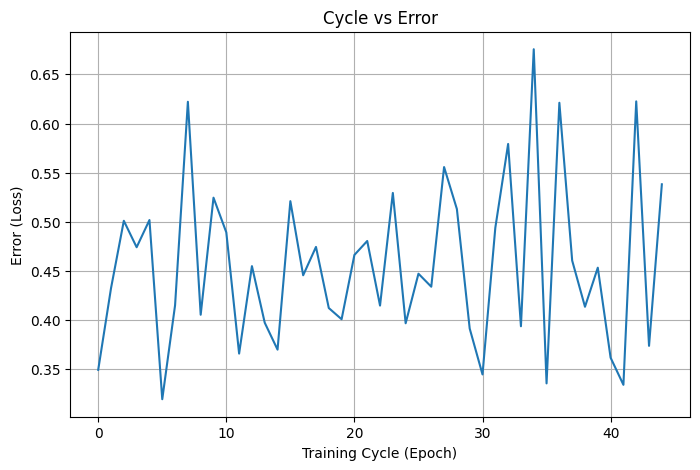

In [91]:
import matplotlib.pyplot as plt

cycles = range(1, len(train_loss_history)+1)

plt.figure(figsize=(8,5))
plt.plot(final_epoch_loss[::10])
# plt.plot(cycles, step_losses)

plt.xlabel("Training Cycle (Epoch)")
plt.ylabel("Error (Loss)")
plt.title("Cycle vs Error")
plt.grid()

plt.show()

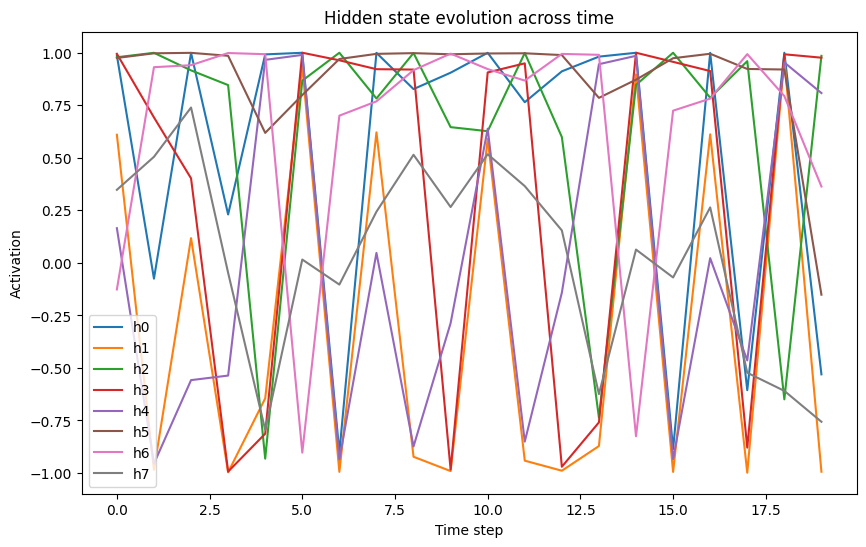

In [92]:
import matplotlib.pyplot as plt
import torch

model.eval()

with torch.no_grad():

    X,y=__builtins__.next(iter(test_loader))
    X = X.to(device)

    _, hidden_states = model(X, return_hidden=True)

    # Convert list → tensor
    # Shape:
    # (seq_len,batch_size,hidden_size)

    hidden_states = torch.stack(hidden_states)

    # Take first sample only
    # Result:
    # (seq_len,hidden_size)

    hidden_sample = hidden_states[:,0,:]

    hidden_sample = hidden_sample.cpu()


plt.figure(figsize=(10,6))

for neuron in range(hidden_size):
    plt.plot(
        hidden_sample[:,neuron],
        label=f"h{neuron}"
    )

plt.xlabel("Time step")
plt.ylabel("Activation")
plt.title("Hidden state evolution across time")

plt.legend()
plt.show()